In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:

import pandas as pd
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   idSecuencia       625800 non-null  datetime64[ns]
 1   producto          625800 non-null  int64         
 2   udsVenta          625800 non-null  int64         
 3   bolPromocion      625800 non-null  int64         
 4   bolOpen           625800 non-null  int64         
 5   bolHoliday        625800 non-null  int64         
 6   udsStock          625800 non-null  int64         
 7   rotura_stock      625800 non-null  bool          
 8   dia_semana        625800 non-null  int64         
 9   mes               625800 non-null  int64         
 10  semana            625800 non-null  int64         
 11  lag_ventas_1      625800 non-null  float64       
 12  lag_ventas_2      625800 non-null  float64       
 13  lag_ventas_3

# LightGBM

El algoritmo **LightGBM** (Light Gradient Boosting Machine) es una implementación altamente eficiente de los **Gradient Boosting Decision Trees (GBDT)**, un potente método de **aprendizaje de conjunto (*ensemble*)** que utiliza una estrategia de **Boosting**.

A diferencia de Random Forest, que utiliza *bagging* (entrenamiento en paralelo de árboles descorrelacionados) [Previous response], LightGBM construye sus modelos de forma **secuencial** para optimizar la predicción.

**Bases de LightGBM (GBDT)**

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   **Aprendizaje Aditivo:** LightGBM entrena una serie de **aprendices débiles** (generalmente árboles de decisión) de forma secuencial, donde cada nuevo árbol intenta **corregir los errores** de la suma acumulada de los árboles anteriores.
    *   **Optimización por Gradiente:** El proceso de construcción de árboles está dirigido por la **minimización del gradiente** de la función de pérdida. Específicamente, los árboles se ajustan a los **pseudo-residuales** (el gradiente negativo de la función de pérdida) de la iteración anterior.
    *   **Predicción Final:** La predicción se obtiene mediante una **suma ponderada** de las salidas de todos los árboles en el *ensemble*.

2.  **Eficiencia y Escalabilidad (Innovación):**
    *   LightGBM se destaca por su **velocidad y rendimiento superior**, logrando una **drástica reducción en el tiempo de entrenamiento** en comparación con otras implementaciones de GBDT.
    *   **Paralelización:** A pesar de la naturaleza secuencial del *boosting*, LightGBM emplea **múltiples estrategias de paralelización** (incluyendo paralelización por características, por datos y por votación) para acelerar el cálculo.

3.  **Robustez y Manejo de Datos:**
    *   **Manejo de Datos Categóricos:** LightGBM tiene un soporte nativo para características categóricas. Determina el *split* óptimo ordenando los valores categóricos en función de las **estadísticas objetivo promedio** (*average target statistics*).
    *   **Imputación y Normalización:** El algoritmo está diseñado para **manejar valores faltantes de forma nativa**. Además, **no es sensible a la normalización de los datos**.
    *   **Regularización:** Dado que los algoritmos de *boosting* son propensos al sobreajuste (alta varianza), LightGBM incorpora técnicas de **regularización** explícitas (como la **tasa de aprendizaje/shrinkage**) y regularización **L1 y L2** directamente en el objetivo para controlar la complejidad del modelo.

LightGBM es un modelo de **alta precisión** que utiliza un enfoque de **regresión de árbol basado en gradiente** y es una opción sólida para la regresión y el pronóstico, especialmente en escenarios donde la velocidad y el manejo eficiente de grandes conjuntos de datos son cruciales.

# Preparación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE LIGHTGBM


# LightGBM global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de LightGBM para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:
# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (LightGBM)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: LIGHTGBM GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")




🔍 MODELO 1: LIGHTGBM GLOBAL

✅ X_train shape: (521202, 16)
✅ X_test shape: (23244, 16)

✅ X_tr shape: (416962, 16)
✅ X_val shape: (104240, 16)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)

✅ X_train shape: (521202, 16)
✅ X_test shape: (23244, 16)

✅ X_tr shape: (416962, 16)
✅ X_val shape: (104240, 16)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:

print("\n🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA LIGHTGBM
# =====================================================

def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt','dart']),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', -1, 12),  # -1 significa sin límite
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    model = lgb.LGBMRegressor(**params, random_state=42)

    # Entrenar con early stopping
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(50)])
    
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse


# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...")
start_time = time.perf_counter()

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=5, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros LightGBM:")
print(study_lgb.best_params)


[I 2025-12-03 20:06:21,330] A new study created in memory with name: no-name-75fb6bfd-6803-4b9c-a74f-1396908cc56e



🔎 Búsqueda de hiperparámetros con Optuna para LightGBM...

🔍 Iniciando optimización de hiperparámetros con Optuna para LightGBM...
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[419]	valid_0's rmse: 1.97425
Early stopping, best iteration is:
[419]	valid_0's rmse: 1.97425


[I 2025-12-03 20:06:31,058] Trial 0 finished with value: 3.897669396158854 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 123, 'n_estimators': 1174, 'learning_rate': 0.06502948607219995, 'max_depth': 3, 'min_child_samples': 59, 'bagging_fraction': 0.7542090343320654, 'bagging_freq': 2, 'feature_fraction': 0.8516398792752403, 'reg_lambda': 2.411992391836521, 'reg_alpha': 2.9156920393377277, 'min_split_gain': 0.7390285113452569}. Best is trial 0 with value: 3.897669396158854.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[192]	valid_0's rmse: 1.9713
Early stopping, best iteration is:
[192]	valid_0's rmse: 1.9713


[I 2025-12-03 20:06:37,522] Trial 1 finished with value: 3.886030451140575 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 75, 'n_estimators': 836, 'learning_rate': 0.06652060920130397, 'max_depth': 9, 'min_child_samples': 82, 'bagging_fraction': 0.6379156714893537, 'bagging_freq': 1, 'feature_fraction': 0.6197834618569559, 'reg_lambda': 1.8419357984355023, 'reg_alpha': 2.502032372955986, 'min_split_gain': 0.8901445660119416}. Best is trial 1 with value: 3.886030451140575.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[450]	valid_0's rmse: 1.97391
Early stopping, best iteration is:
[450]	valid_0's rmse: 1.97391


[I 2025-12-03 20:06:47,700] Trial 2 finished with value: 3.8963328218836843 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 30, 'n_estimators': 722, 'learning_rate': 0.06454268186964658, 'max_depth': 3, 'min_child_samples': 80, 'bagging_fraction': 0.8536435002774199, 'bagging_freq': 3, 'feature_fraction': 0.6209178089380836, 'reg_lambda': 1.9782914864835184, 'reg_alpha': 1.9142139976590364, 'min_split_gain': 0.7737207478083269}. Best is trial 1 with value: 3.886030451140575.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1122]	valid_0's rmse: 1.9752
Did not meet early stopping. Best iteration is:
[1122]	valid_0's rmse: 1.9752


[I 2025-12-03 20:07:05,798] Trial 3 finished with value: 3.9014318080038644 and parameters: {'boosting_type': 'gbdt', 'num_leaves': 129, 'n_estimators': 1123, 'learning_rate': 0.010728210296732201, 'max_depth': 3, 'min_child_samples': 12, 'bagging_fraction': 0.7039002891292426, 'bagging_freq': 4, 'feature_fraction': 0.9181671506963336, 'reg_lambda': 0.7161518400210719, 'reg_alpha': 2.790566647870312, 'min_split_gain': 0.9188728989418788}. Best is trial 1 with value: 3.886030451140575.
[I 2025-12-03 20:07:45,332] Trial 4 finished with value: 3.911100575006774 and parameters: {'boosting_type': 'dart', 'num_leaves': 138, 'n_estimators': 419, 'learning_rate': 0.08334001474435522, 'max_depth': 3, 'min_child_samples': 66, 'bagging_fraction': 0.658590334845574, 'bagging_freq': 2, 'feature_fraction': 0.6372566736835716, 'reg_lambda': 0.9009154598610357, 'reg_alpha': 2.8864322338990034, 'min_split_gain': 0.5800101542844286}. Best is trial 1 with value: 3.886030451140575.
[I 2025-12-03 20:07:45,

✅ Optuna completado en 84.00 segundos

🏆 Mejores hiperparámetros LightGBM:
{'boosting_type': 'gbdt', 'num_leaves': 75, 'n_estimators': 836, 'learning_rate': 0.06652060920130397, 'max_depth': 9, 'min_child_samples': 82, 'bagging_fraction': 0.6379156714893537, 'bagging_freq': 1, 'feature_fraction': 0.6197834618569559, 'reg_lambda': 1.8419357984355023, 'reg_alpha': 2.502032372955986, 'min_split_gain': 0.8901445660119416}


In [9]:
print("\nEntrenando modelo LIGTHgbm con mejores hiperparámetros en todo el conjunto de entrenamiento...")
best_lgb = lgb.LGBMRegressor(
    **study_lgb.best_params,
    random_state=42,
    n_jobs=-1)

best_lgb.fit(X_train, y_train)



Entrenando modelo LIGTHgbm con mejores hiperparámetros en todo el conjunto de entrenamiento...


,boosting_type,'gbdt'
,num_leaves,75
,max_depth,9
,learning_rate,0.06652060920130397
,n_estimators,836
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.8901445660119416
,min_child_weight,0.001
,min_child_samples,82


In [10]:
from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_lgb.predict(X_test)

# Calcular métricas
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='LightGBM', ndetalle='Global', cluster=None, producto=None)

# todas_metricas.append(metricas_train_global)
todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='LightGBM', ndetalle='Global', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='LightGBM',
            ndetalle='Global', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)

resumen_metricas(todas_metricas)    



📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM   Global    None     None 1.5723 2.3796 0.2611     50.09     144.77 0.7292    96.29

🏆 Mejor modelo: LightGBM (RMSE: 2.3796)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM   Global      3.0     314.0 0.2412  0.3424  0.0000       NaN     200.00    NaN      NaN
 LightGBM   Global      3.0     257.0 0.7821  1.1357  0.0279     75.77     185.80 0.7728   156.42
 LightGBM   Global      3.0       NaN 1.0825  1.6489  0.0889     55.67     169.16 0.7399   133.30
 LightGBM   Global      0.0     413.0 1.7109  2.1453  0.0492     33.25     101.39 0.7510    82.37
 LightGBM   Global      NaN       NaN 1.5723  2.3796  0.2611     50.09     144.77 0.7292    96.29
 LightGBM   Global      0.0       NaN 1.7948  2.5455  0.1197     40.12     126.07 0.7318    92.95
 LightGB

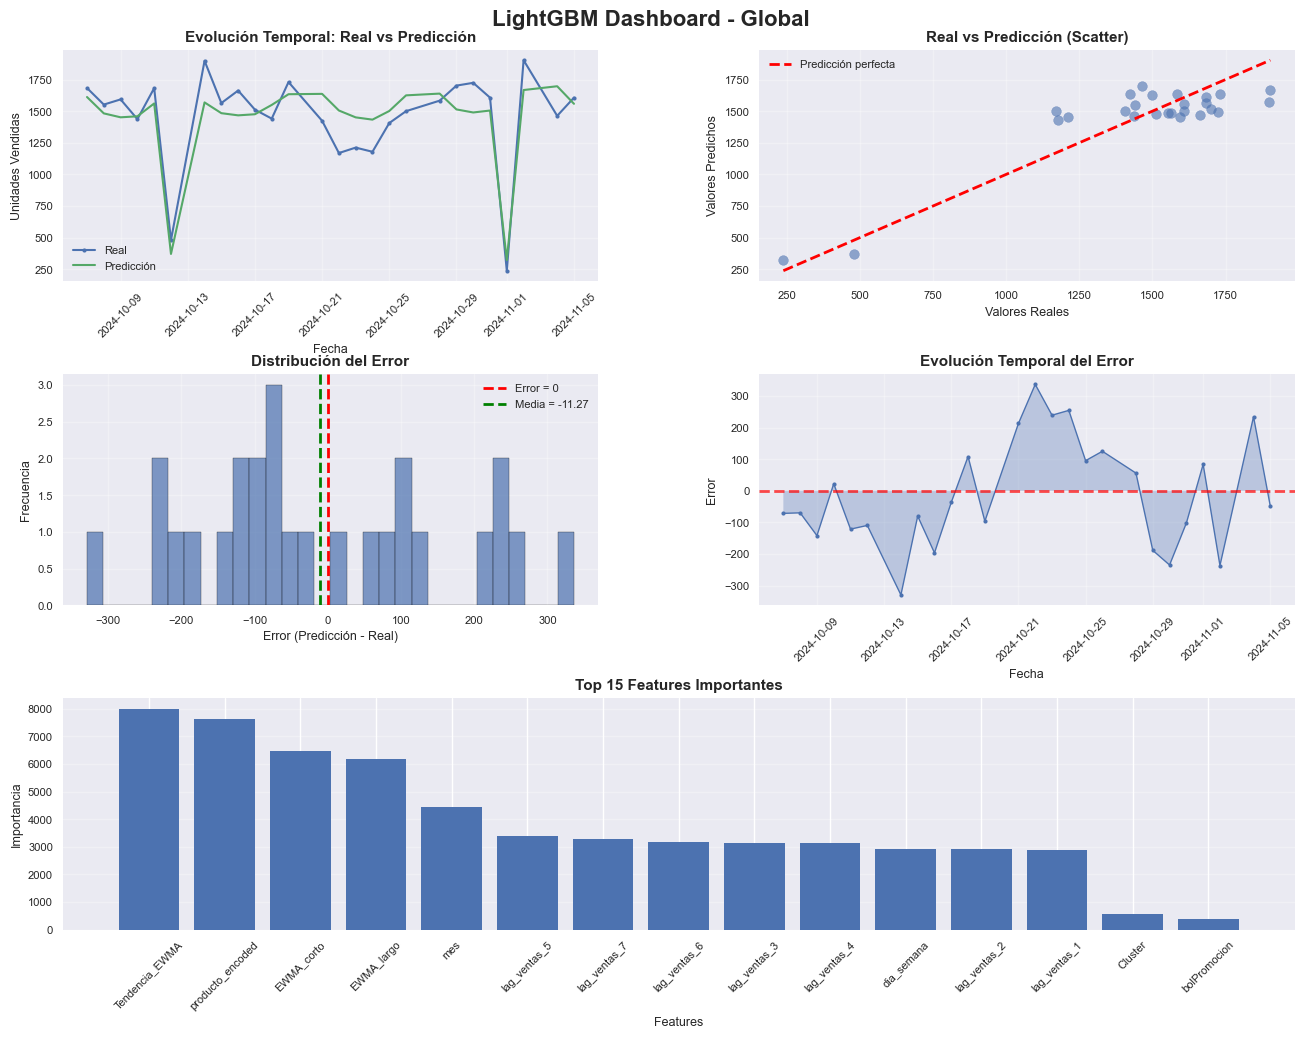

In [11]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_lgb,
        feature_names=FEATURES,
        titulo_principal=f'LightGBM Dashboard - Global'
        )

# LightGBM por Cluster


📍 MODELO 2: LightGBM POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        0     None 1.8112 2.5685 0.1037     40.69     126.35 0.7384     93.8

🏆 Mejor modelo: LightGBM (RMSE: 2.5685)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        0     None 1.8112 2.5685 0.1037     40.69     126.35 0.7384     93.8

🏆 Mejor modelo: LightGBM (RMSE: 2.5685)


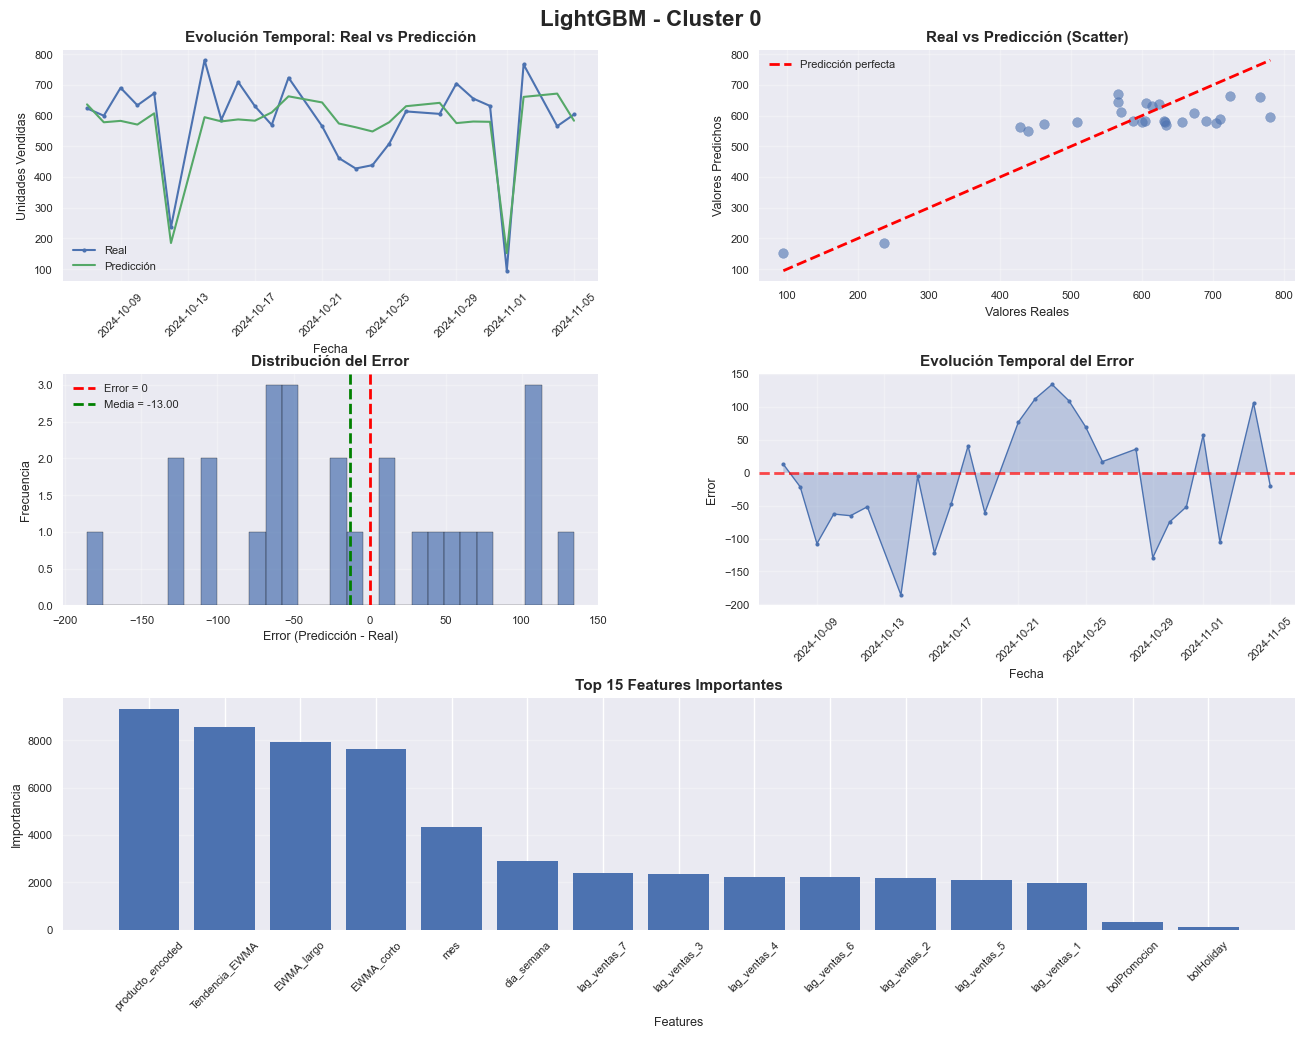


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        1     None 2.8368 3.6713 0.1035     57.23      99.71 0.7337     74.4

🏆 Mejor modelo: LightGBM (RMSE: 3.6713)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        1     None 2.8368 3.6713 0.1035     57.23      99.71 0.7337     74.4

🏆 Mejor modelo: LightGBM (RMSE: 3.6713)


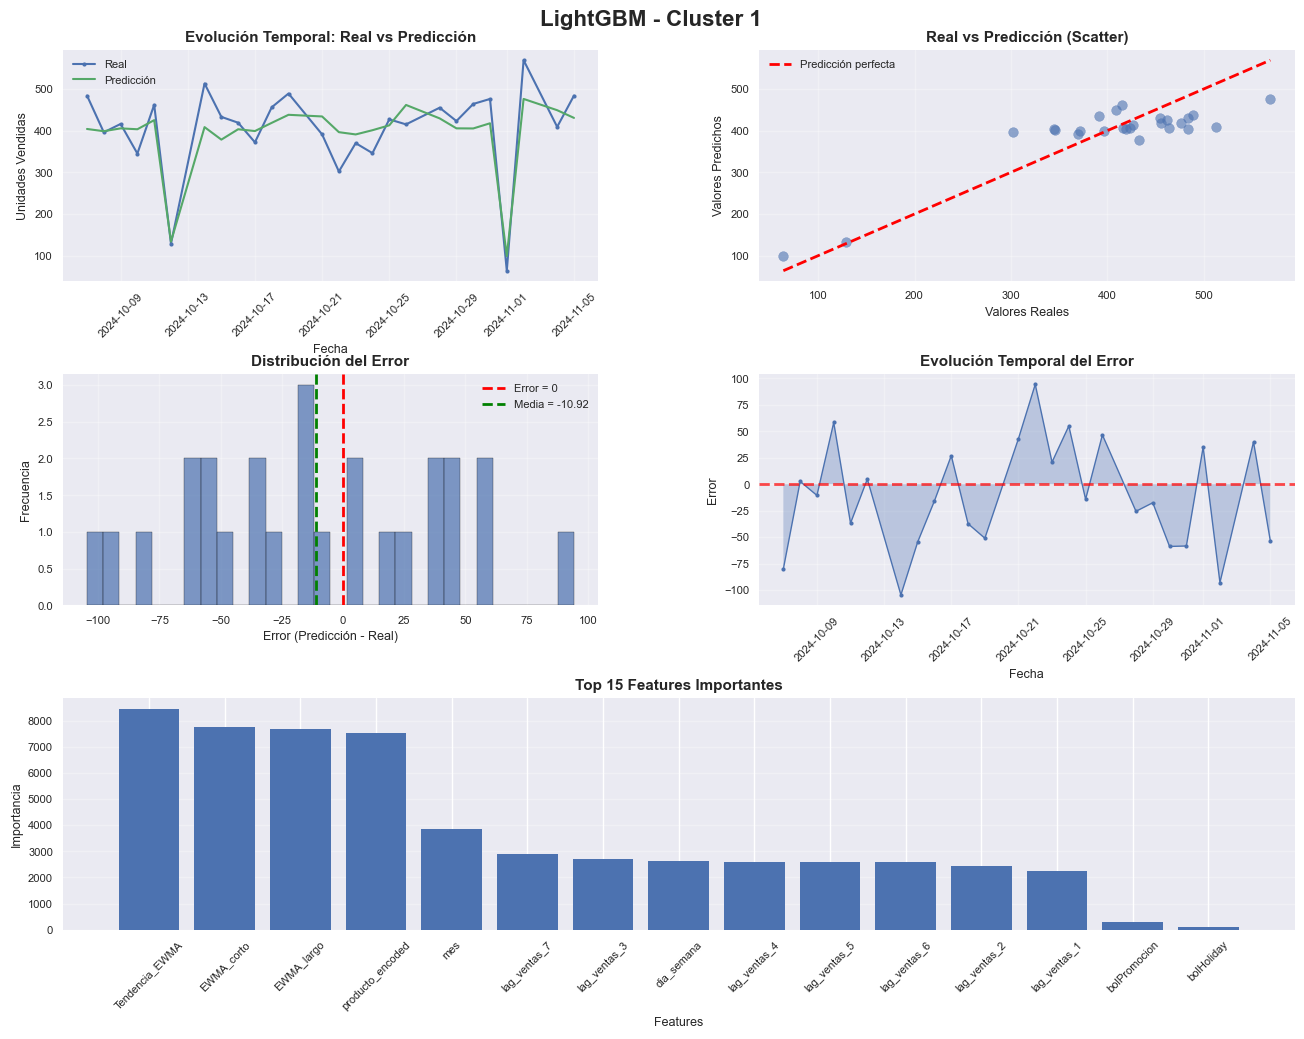


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        2     None 3.8594 5.3706 0.1087      78.7      82.76 0.7468     67.2

🏆 Mejor modelo: LightGBM (RMSE: 5.3706)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        2     None 3.8594 5.3706 0.1087      78.7      82.76 0.7468     67.2

🏆 Mejor modelo: LightGBM (RMSE: 5.3706)


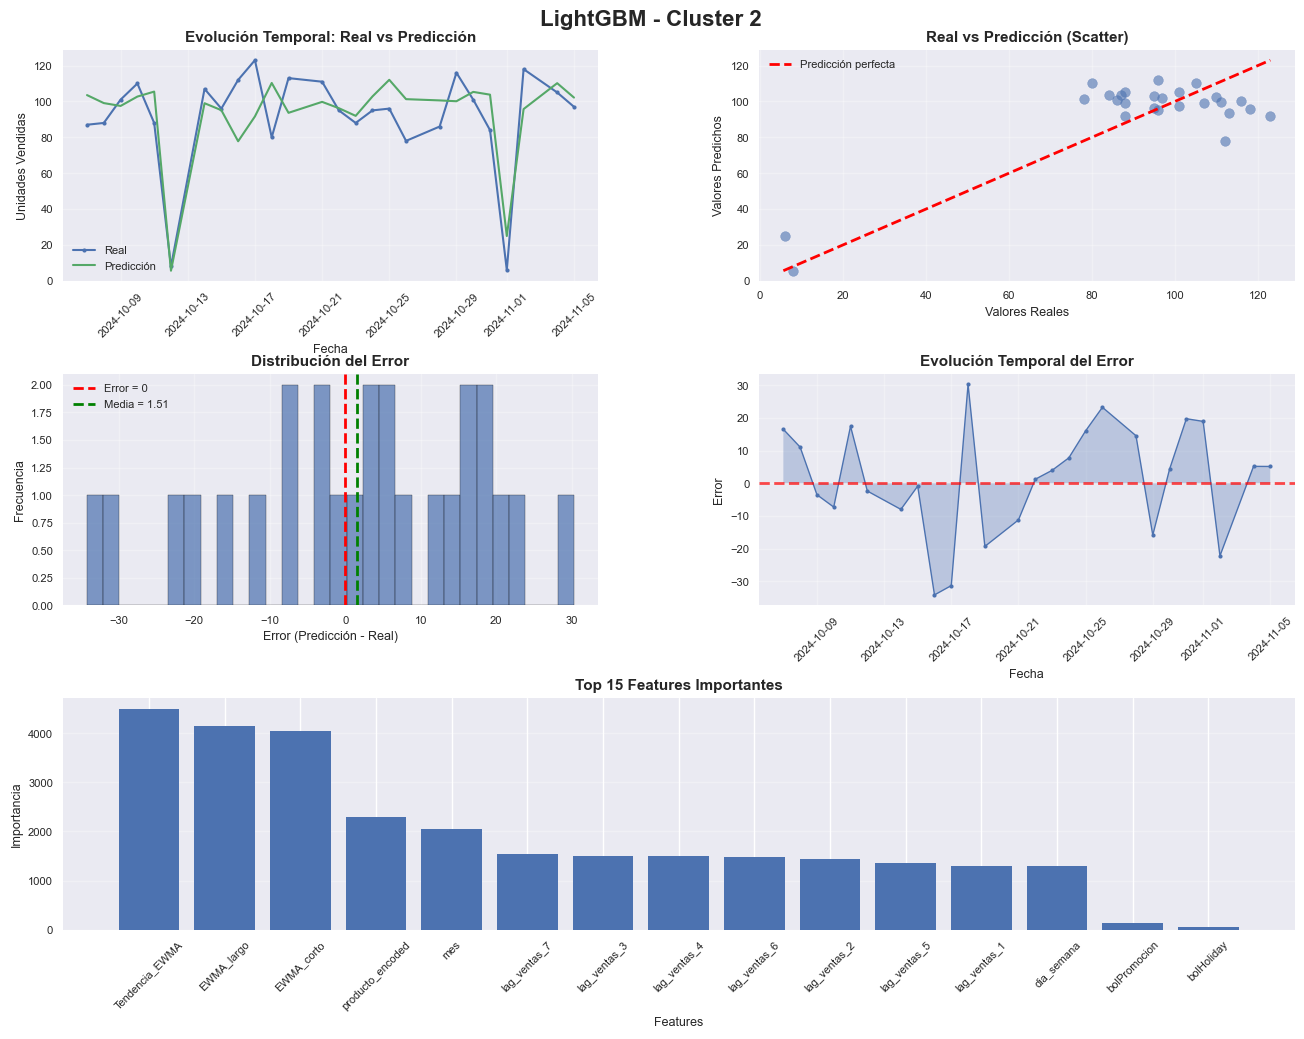


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        3     None 1.0947 1.6714 0.064     57.17     169.83   0.75    134.8

🏆 Mejor modelo: LightGBM (RMSE: 1.6714)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster        3     None 1.0947 1.6714 0.064     57.17     169.83   0.75    134.8

🏆 Mejor modelo: LightGBM (RMSE: 1.6714)


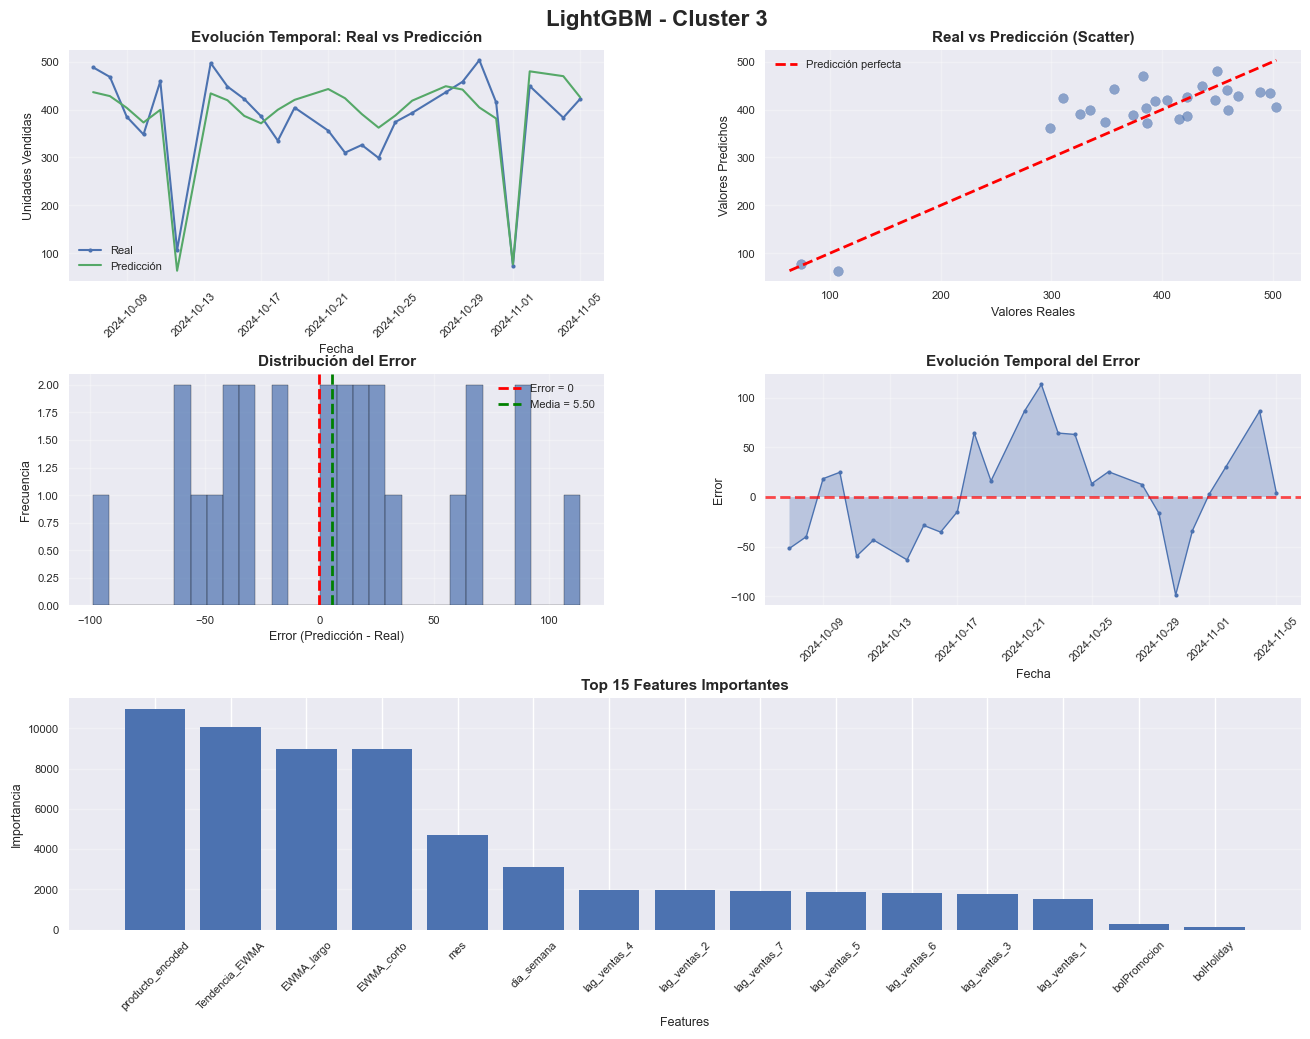

In [12]:
# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 2: LightGBM POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
    
    # Entrenar
    lgb_cluster = lgb.LGBMRegressor(
        **study_lgb.best_params,
        random_state=42,
        n_jobs=-1)
    
    lgb_cluster.fit(X_train_c, y_train_c)
    y_pred_c = lgb_cluster.predict(X_test_c)
    
    # Calcular métricas y GUARDAR
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="LightGBM", ndetalle='Cluster', cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='LightGBM',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=lgb_cluster,
        feature_names=FEATURES,
        titulo_principal=f'LightGBM - Cluster {cluster}'
        )
  


# LightGBM por top 2 productos de ventas por cluster


📍 MODELO 3: LIGHTGBM POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        0       413 1.794 2.2251 -0.0229      41.3     108.99 0.7789    86.38

🏆 Mejor modelo: LightGBM (RMSE: 2.2251)


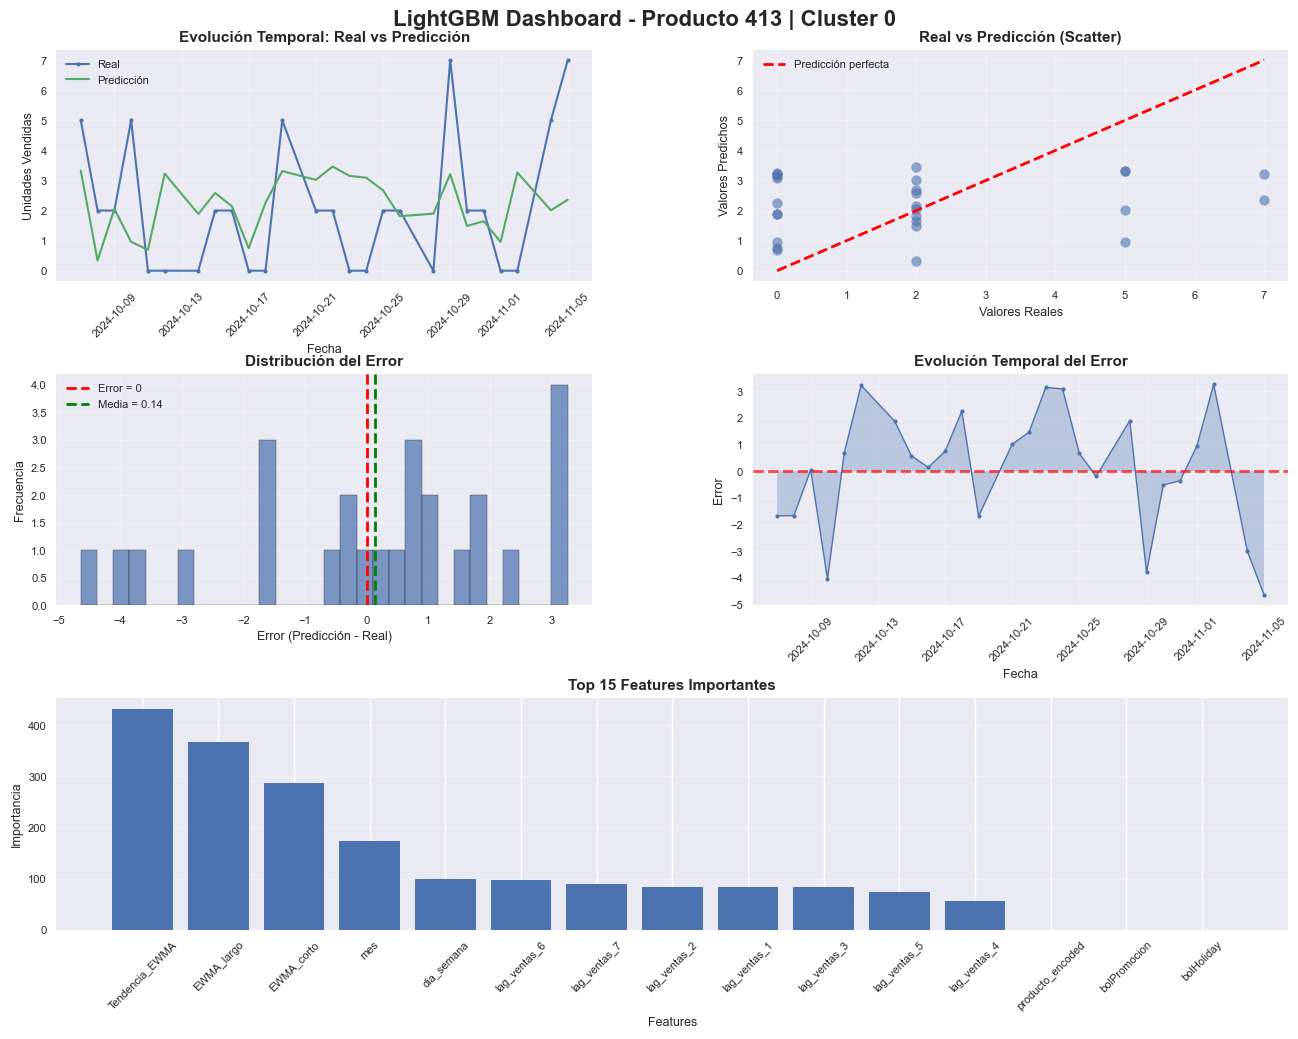


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        0       294 2.5118 3.233 -0.3104      48.5     132.37 0.7448   136.05

🏆 Mejor modelo: LightGBM (RMSE: 3.2330)


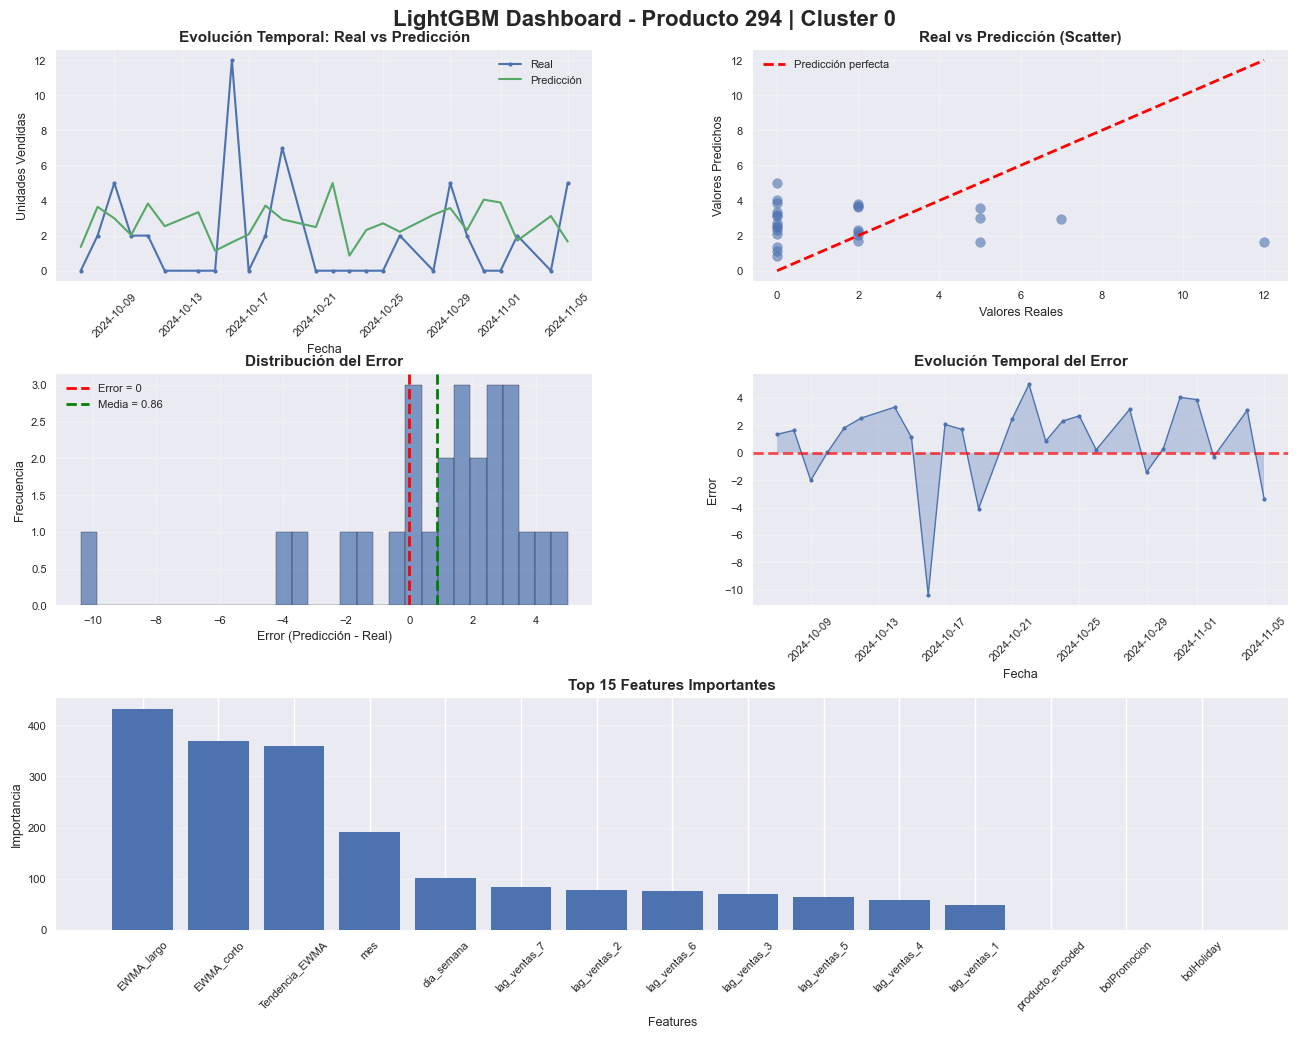


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        1       144 4.7626 5.8527 -0.3335     89.07      91.85 0.8748    84.24

🏆 Mejor modelo: LightGBM (RMSE: 5.8527)


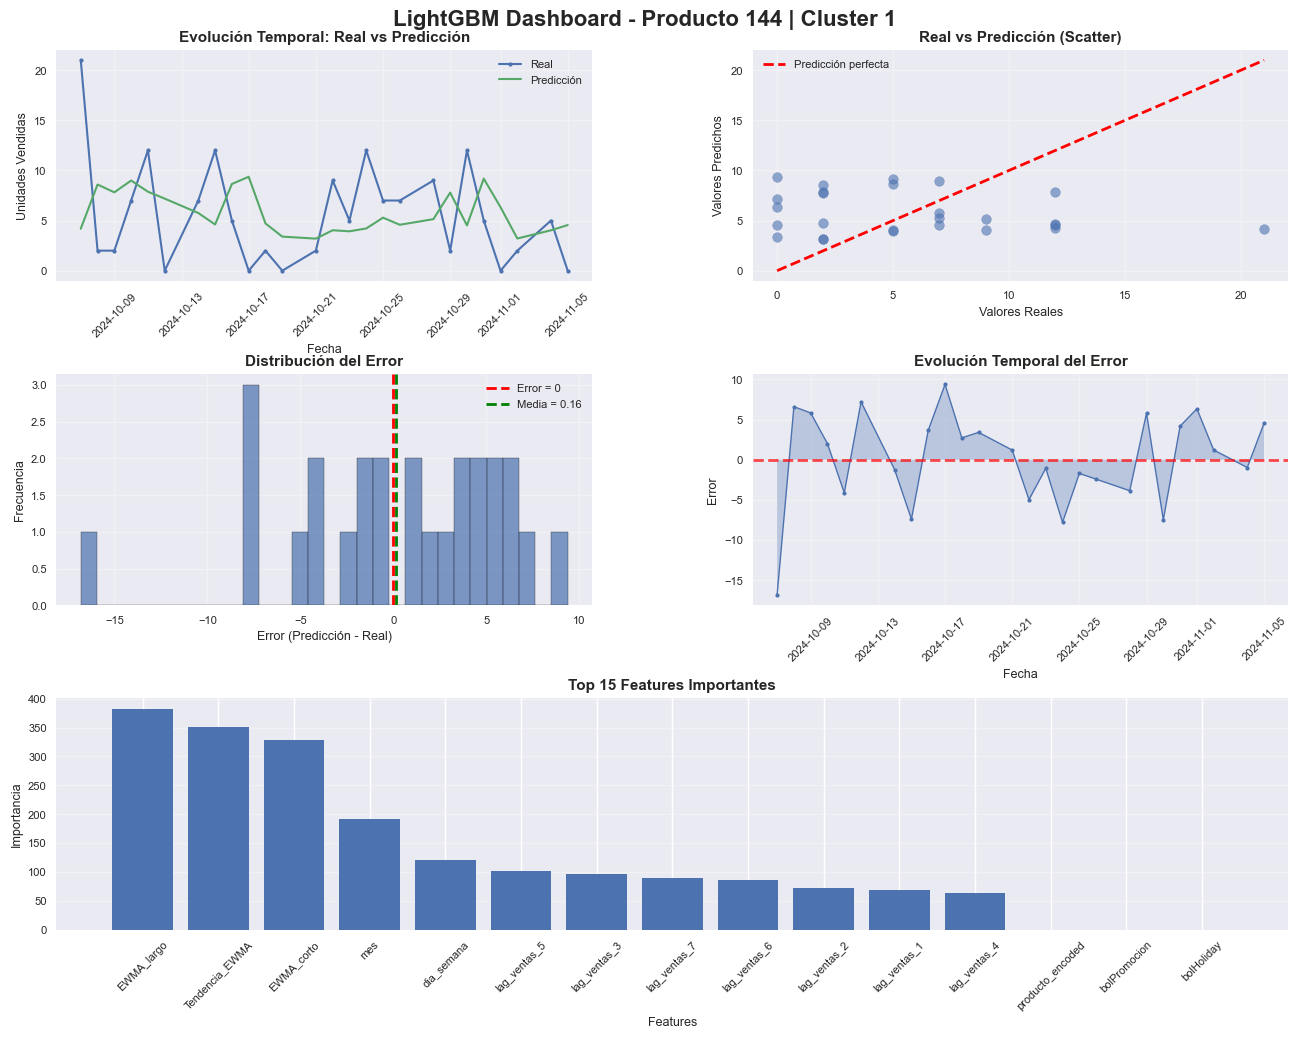


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        1        41 3.6746 4.7671 -0.1145     64.19      65.17 0.8137    55.55

🏆 Mejor modelo: LightGBM (RMSE: 4.7671)


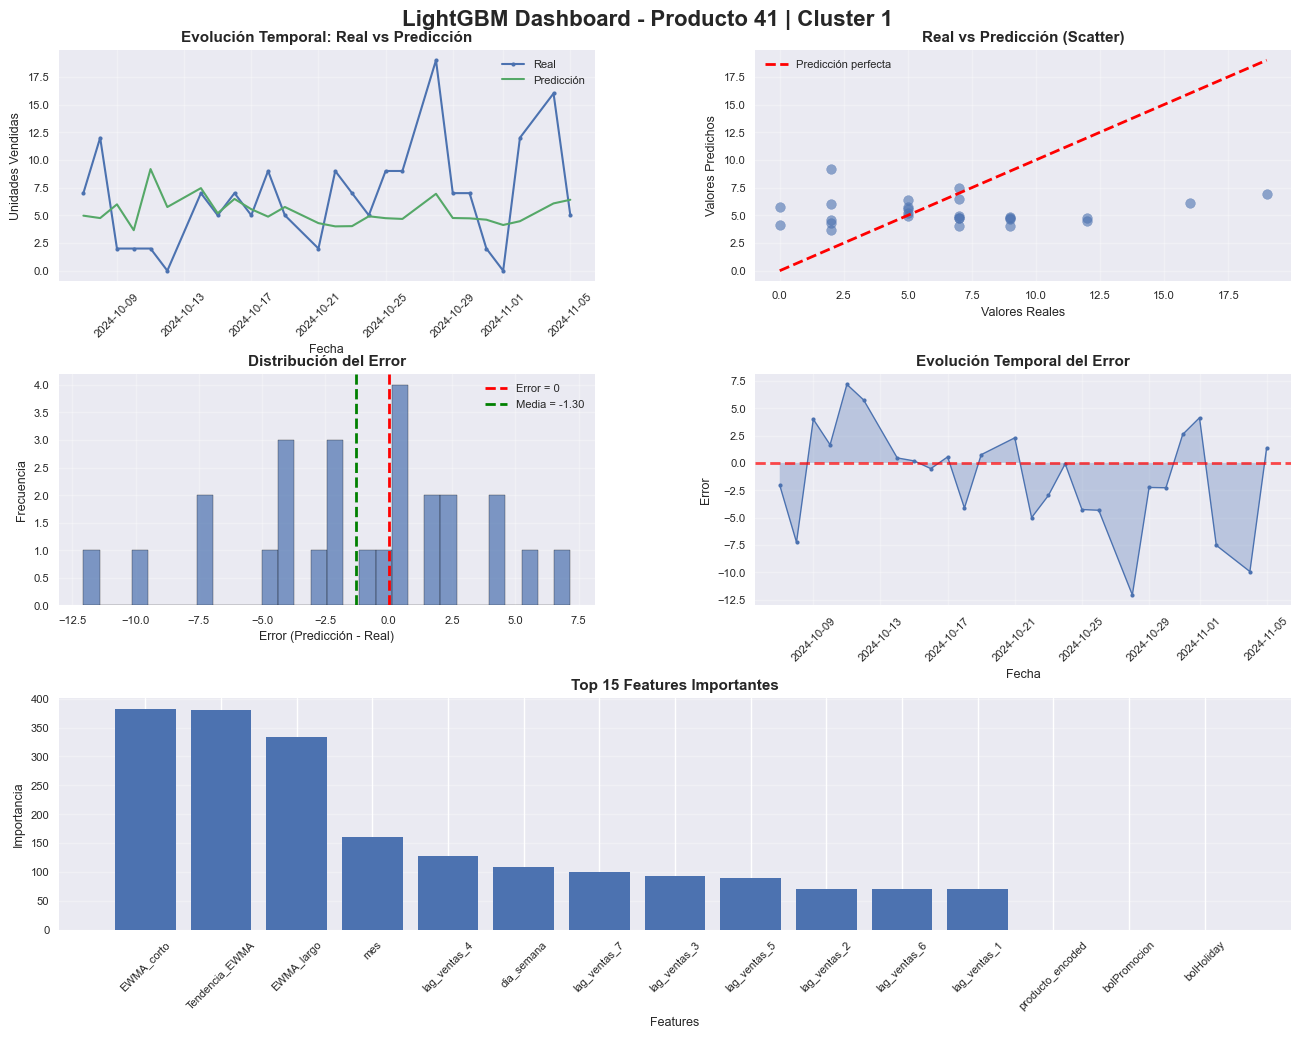


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        2         1 8.7006 12.1349 -0.1868    134.19      78.91  0.764    73.69

🏆 Mejor modelo: LightGBM (RMSE: 12.1349)


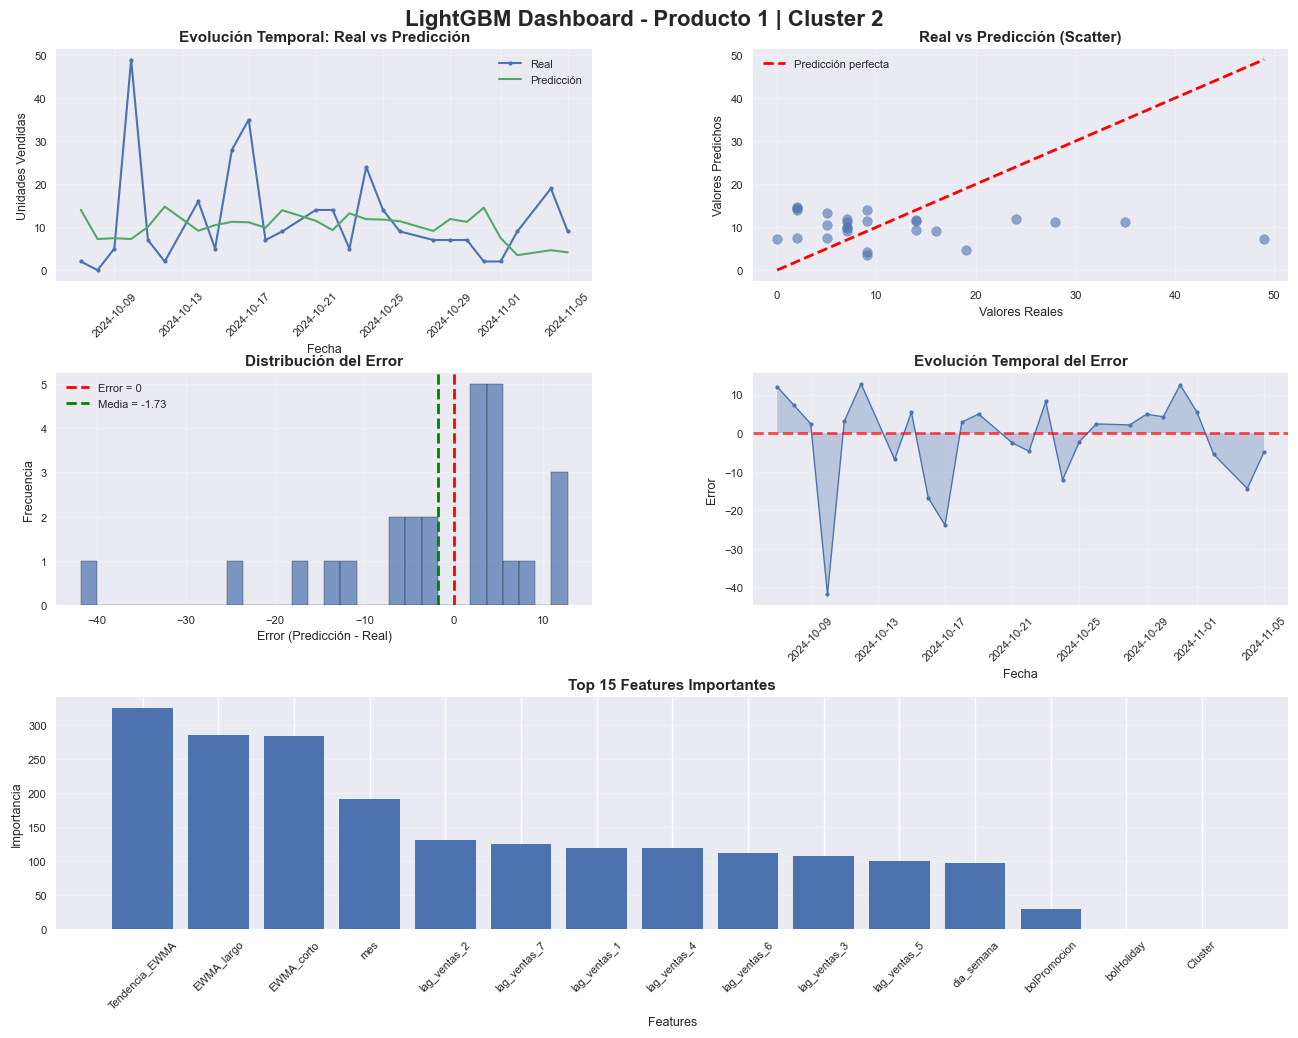


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        2         2 3.8244 4.9297 -0.1887     85.98      64.62 0.6849    60.63

🏆 Mejor modelo: LightGBM (RMSE: 4.9297)


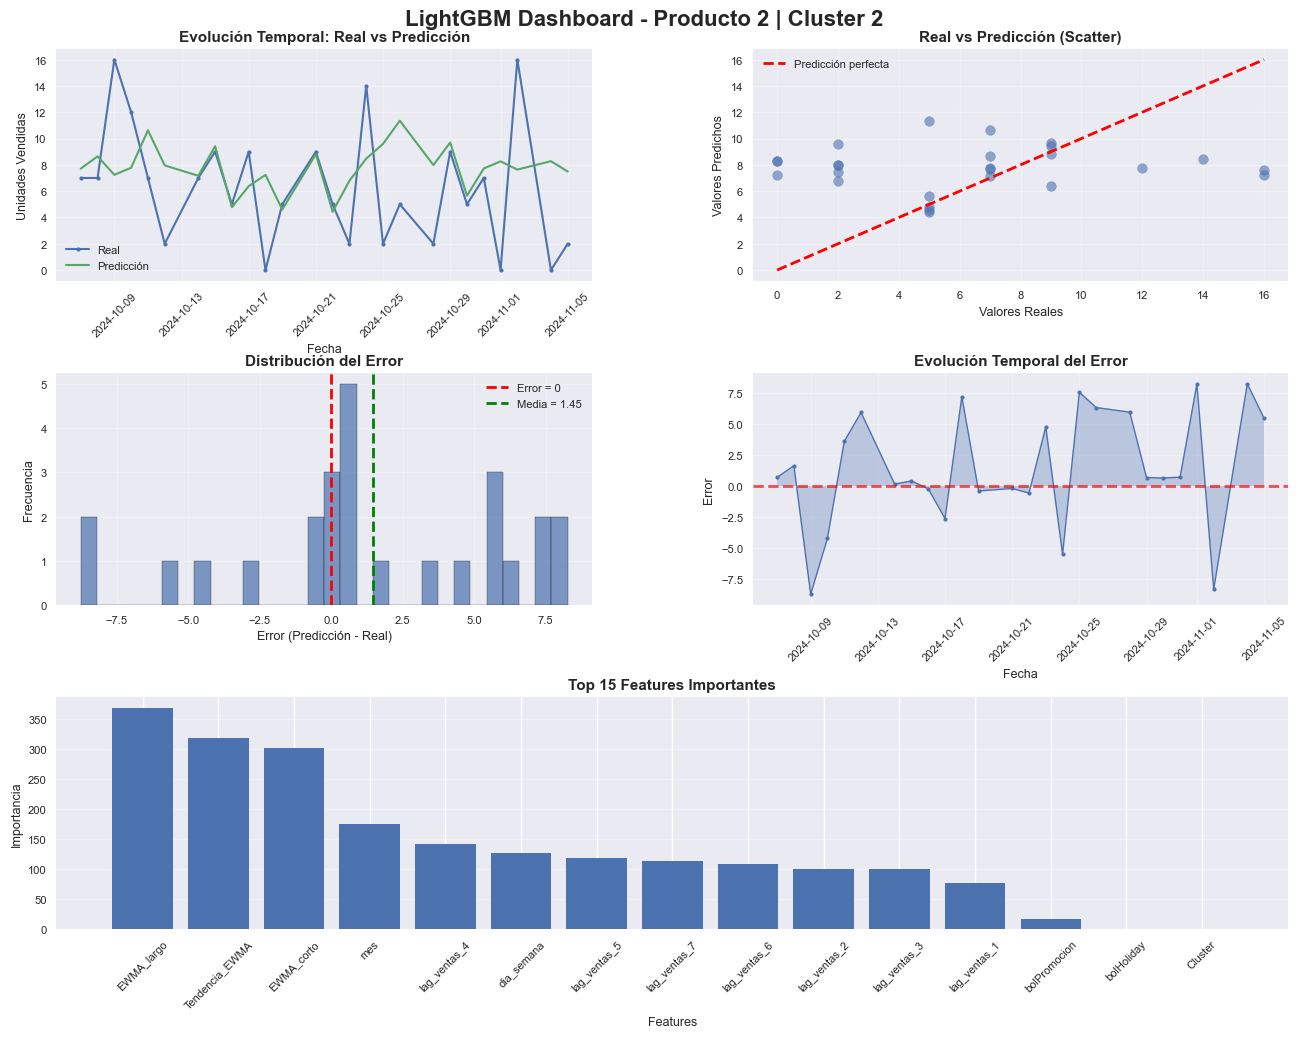


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        3       257 1.2852 1.5029 -0.7021     60.81     179.29 1.0226   257.05

🏆 Mejor modelo: LightGBM (RMSE: 1.5029)


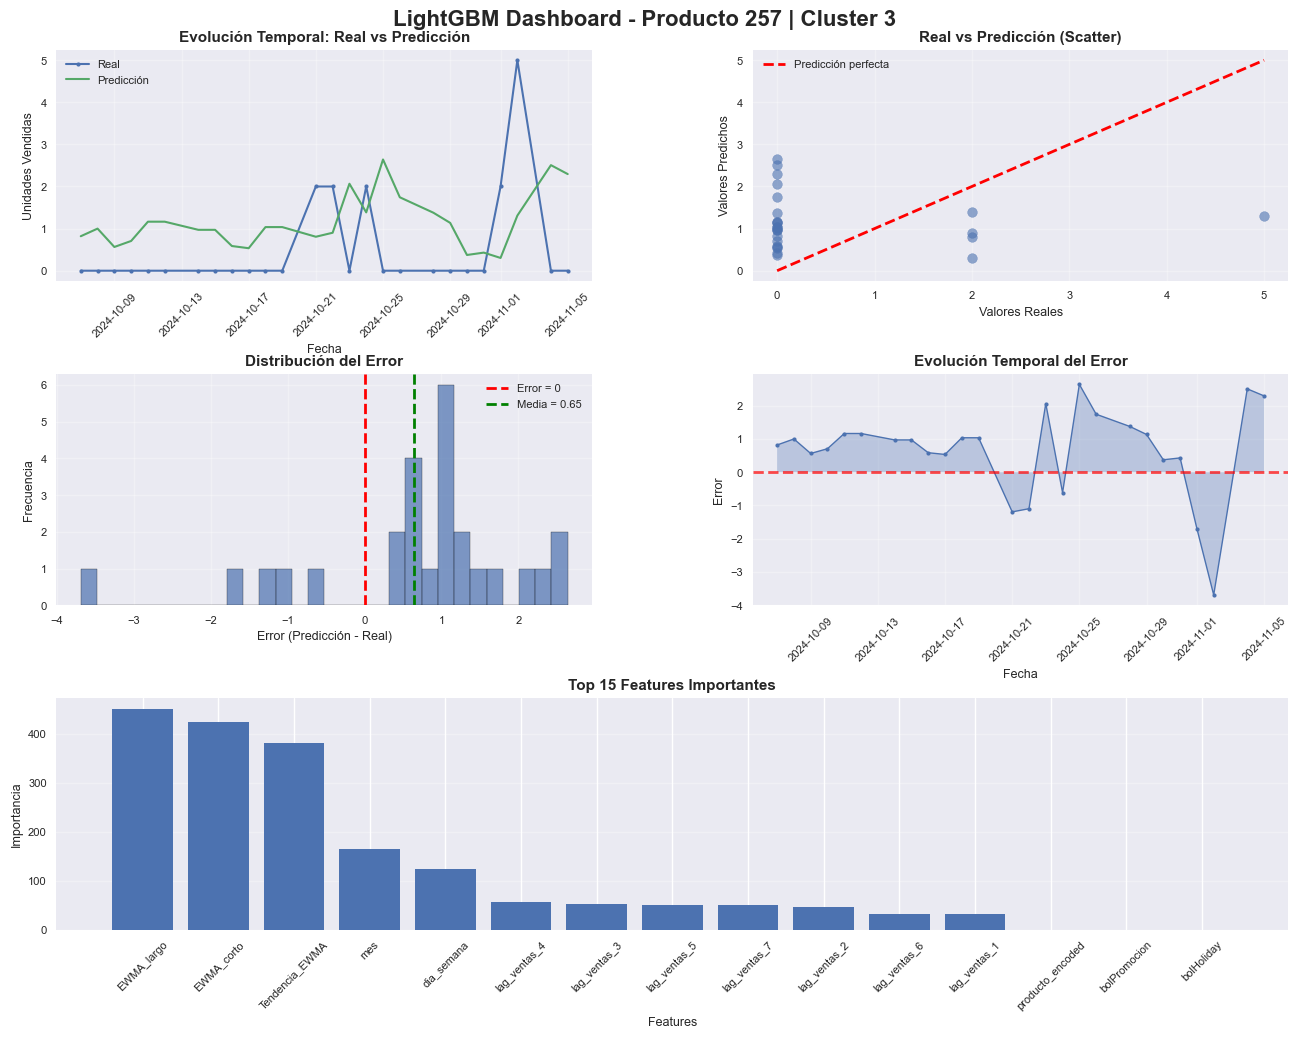


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE  RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM Producto        3       314 0.3894 0.452 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: LightGBM (RMSE: 0.4520)


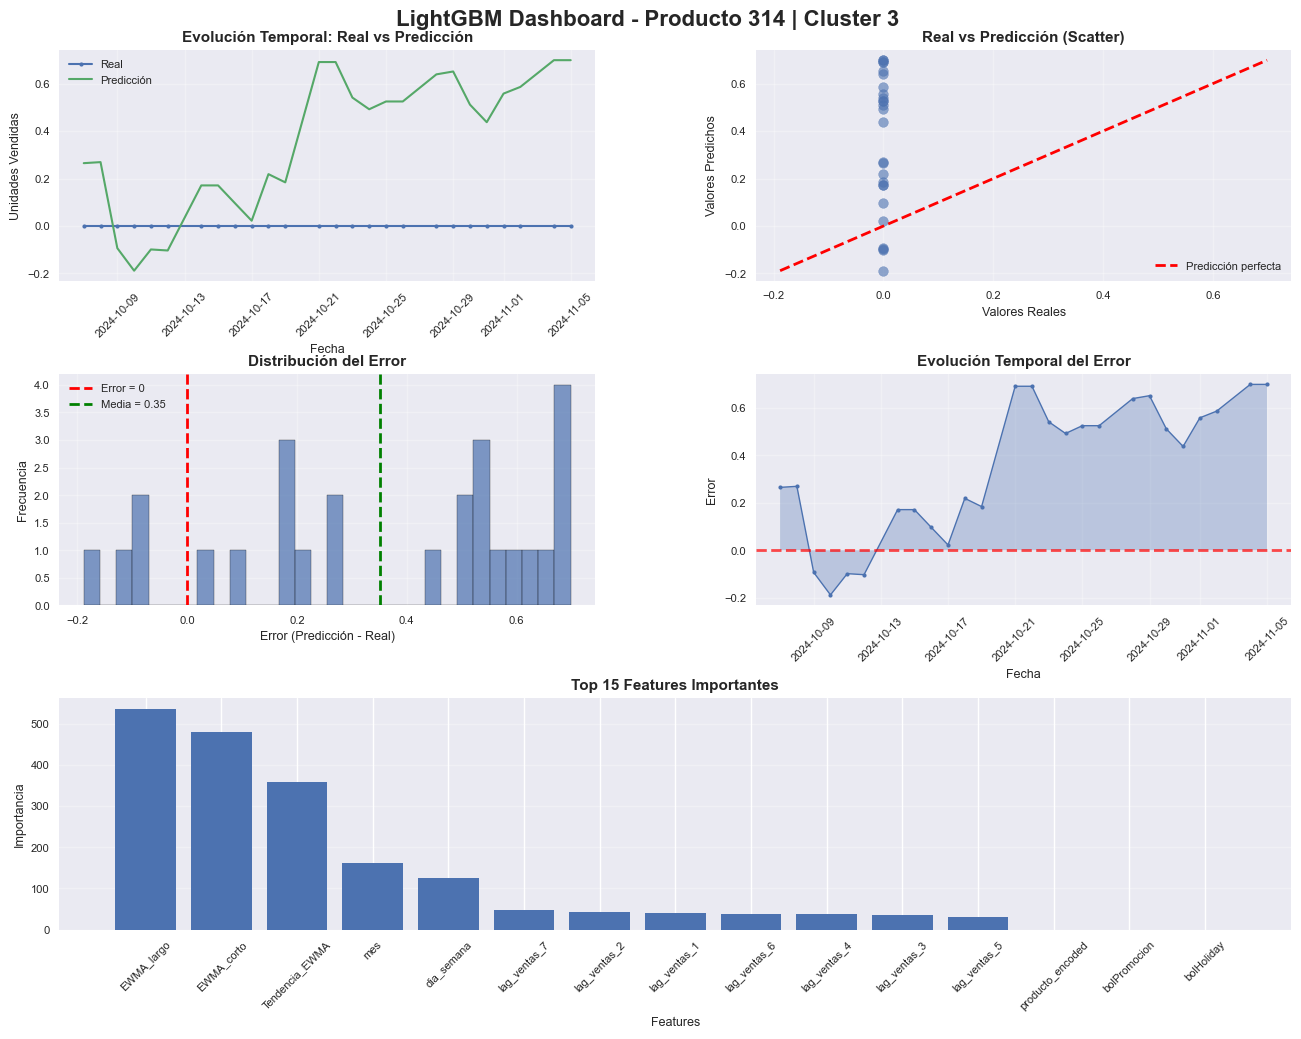


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: LIGHTGBM POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        lgb_producto = lgb.LGBMRegressor(
            **study_lgb.best_params,
            random_state=42,
            n_jobs=-1)
        
        lgb_producto.fit(X_train_p, y_train_p)
        y_pred_p = lgb_producto.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = lgb_producto
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="LightGBM",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=lgb_producto,
            feature_names=FEATURES,
            titulo_principal=f'LightGBM Dashboard - Producto {producto} | Cluster {cluster}'
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

# Salvar resultados

In [14]:
# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 LightGBM  Cluster      3.0     314.0 0.2563   0.0942  0.3070  0.0000       NaN     200.00    NaN      NaN
 LightGBM  Cluster      3.0     257.0 0.9406   1.6276  1.2758 -0.2266     85.55     189.04 0.8680   188.12
 LightGBM  Cluster      3.0       NaN 1.0947   2.7935  1.6714  0.0640     57.17     169.83 0.7500   134.80
 LightGBM  Cluster      0.0     413.0 1.8771   5.3343  2.3096 -0.1021     43.45     109.36 0.8085    90.38
 LightGBM  Cluster      0.0       NaN 1.8112   6.5974  2.5685  0.1037     40.69     126.35 0.7384    93.80
 LightGBM  Cluster      0.0     294.0 2.2531   9.2120  3.0351 -0.1549     42.43     133.29 0.6993   122.04
 LightGBM  Cluster      1.0       NaN 2.8368  13.4782  3.6713  0.1035     57.23      99.71 0.7337    74.40
 LightGBM  Cluster      2.0       2.0

In [15]:
# salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
# Guardar con un nombre distintivo para LightGBM
df_resultados.to_csv('datos/resultados_metricas_lightgbm.csv', index=False)
print("Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'")

Resultados guardados en 'datos/resultados_metricas_lightgbm.csv'
